Data type: uint8
Min. value: 0
Max value: 255


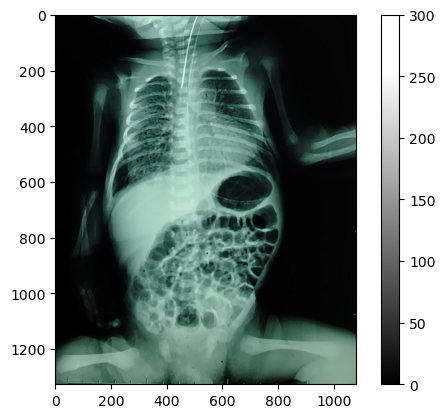

In [1]:
# 1. Importamos las librerías necesarias
import imageio.v2 as imageio  # lector de imágenes
import numpy as np  # operaciones numéricas
import matplotlib.pyplot as plt  # visualización

# 2. Cargamos la imagen radiologica
im = imageio.imread('RXNeonato.jpeg')

# 3. Mostramos información básica de la imagen
print('Data type:', im.dtype)
print('Min. value:', im.min())
print('Max value:', im.max())

# 4. Configuramos los valores de ticks (intervalos para la barra de color)
import matplotlib.ticker as ticker
min_val = 0
max_val = np.max(im)
tick_interval = 50
tick_vals = np.arange(min_val, int(max_val) + tick_interval, tick_interval)

# Mostrar la imagen en escala de grises
plt.imshow(im, vmin=0, vmax=255, cmap='gray')
colorbar = plt.colorbar()
colorbar.set_ticks(tick_vals)

# Renderizar la figura
plt.show()

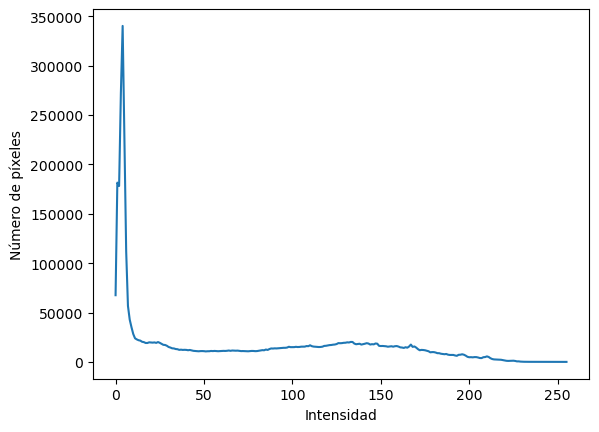

In [2]:
# Import SciPy's "ndimage" module
import scipy.ndimage as ndi
# Create a histogram, binned at each possible value
hist = ndi.histogram(im, min=0, max=255, bins=256)
hist.shape
# Dibujar el Histograma
plt.plot(hist)
plt.xlabel('Intensidad')
plt.ylabel('Número de píxeles')
plt.show()


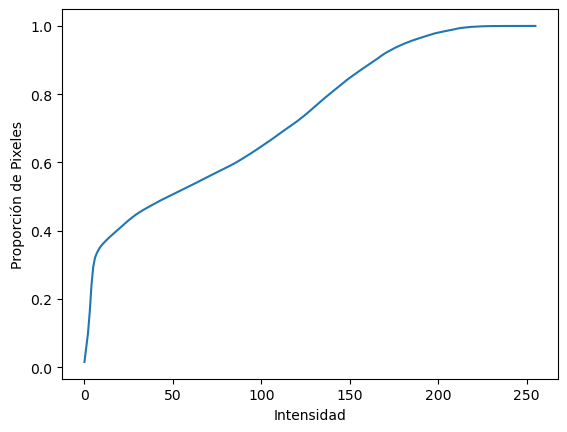

In [3]:
# Create a cumulative distribution function
cdf = hist.cumsum() / hist.sum()
cdf.shape
# Dibujar distribución CDF
plt.plot(cdf)
plt.xlabel('Intensidad')
plt.ylabel('Proporción de Pixeles')
plt.show()

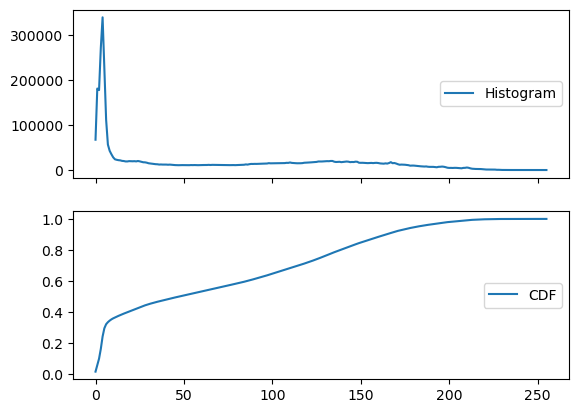

In [4]:
# Plot the histogram and CDF
fig, axes = plt.subplots(2, 1, sharex=True)
axes[0].plot(hist, label='Histogram')
axes[1].plot(cdf, label='CDF')
for ax in fig.axes:
    ax.legend(loc='center right')
plt.show()

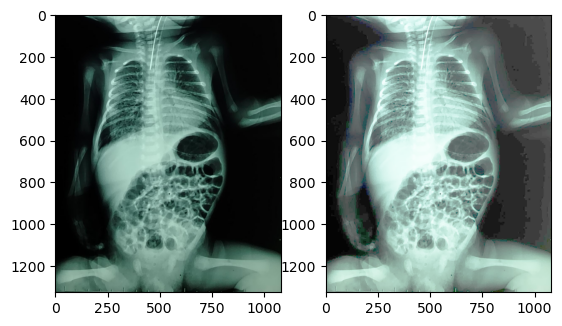

In [5]:
im_ecualizada = (cdf[im] * 255).astype(np.uint8)
fig, axes = plt.subplots(1, 2)
axes[0].imshow(im)
axes[1].imshow(im_ecualizada)
plt.show()

In [6]:
import numpy as np
im = np.array([[10, 20, 80],
[30, 60, 90],
[15, 25, 40]])
mask = im > 50
print(mask)

[[False False  True]
 [False  True  True]
 [False False False]]


In [7]:
mask_range = (im > 30) & (im < 80)
print(mask_range)

[[False False False]
 [False  True False]
 [False False  True]]


In [8]:
masked_im = np.where(mask, im, 0)
print(masked_im)

[[ 0  0 80]
 [ 0 60 90]
 [ 0  0  0]]


In [9]:
im_masked = im.copy()
im_masked[~mask] = 0 # ~ invierte la máscara (False → True)
print(masked_im)


[[ 0  0 80]
 [ 0 60 90]
 [ 0  0  0]]


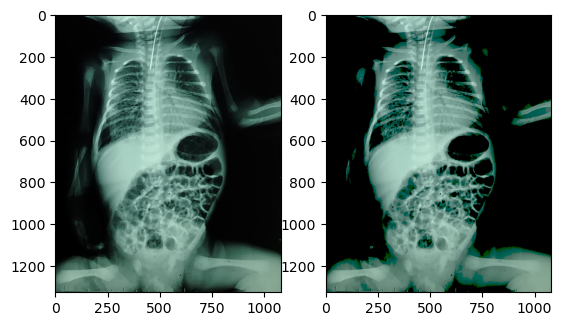

In [10]:
im = imageio.imread('RXNeonato.jpeg')
bone_mask = im > 64
im_masked = im.copy()
im_masked[~bone_mask] = 0
fig, axes = plt.subplots(1, 2)
axes[0].imshow(im)
axes[1].imshow(im_masked, cmap='gray')
plt.show()

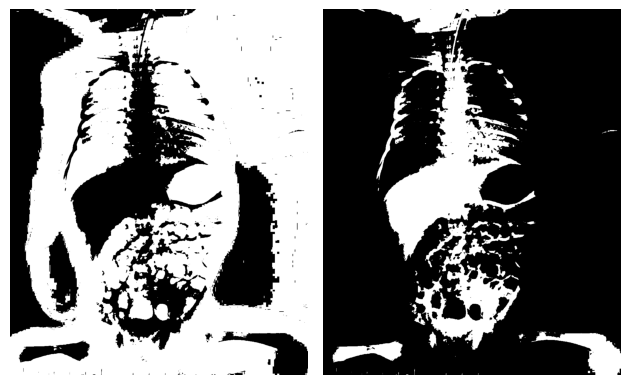

In [11]:
# 1. Importamos las librerías necesarias
import imageio.v2 as imageio # lector de imágenes
import numpy as np # operaciones numéricas
import matplotlib.pyplot as plt # visualización
# Import SciPy's "ndimage" module
import scipy.ndimage as ndi
im = imageio.imread('RXNeonato.jpeg')
# Si la imagen tiene 3 canales (RGB), conviértela a escala de grises
if im.ndim == 3:
    im = np.mean(im, axis=2).astype(np.uint8)
else:
    im = im.astype(np.uint8)
hist = ndi.histogram(im, min=0, max=255, bins=256)
cdf = hist.cumsum() / hist.sum()
im_ecualizada = (cdf[im] * 255).astype(np.uint8)
# Create skin and bone masks
mask_skin = (im_ecualizada >= 50) & (im_ecualizada < 208)
mask_bone = im_ecualizada >=210
# Plot the skin (0) and bone (1) masks
fig, axes = plt.subplots(1,2)
axes[0].imshow(mask_skin, cmap='gray')
axes[1].imshow(mask_bone, cmap='gray')
for ax in fig.axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

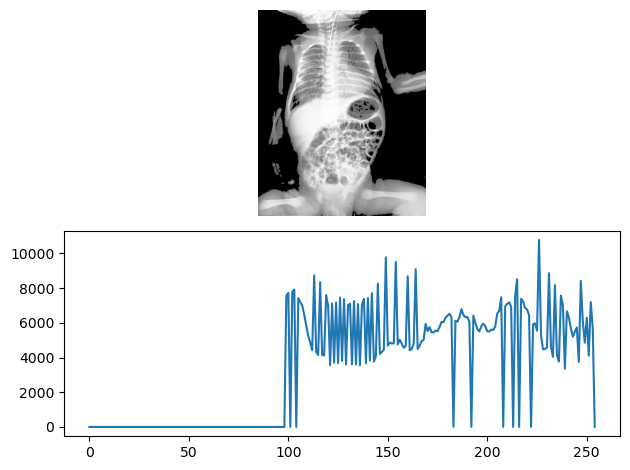

In [31]:
mask_bone = im_ecualizada >= 100
im_bone = np.where(mask_bone, im_ecualizada, 0)
13
# Get the histogram of bone intensities
hist = ndi.histogram(im_bone, min=1, max=255, bins=255)
# Plot masked image and histogram
fig, axes = plt.subplots(2, 1)
fig.axes[0].axis('off')
axes[0].imshow(im_bone, cmap='gray')
axes[1].plot(hist)
plt.tight_layout()
plt.show()

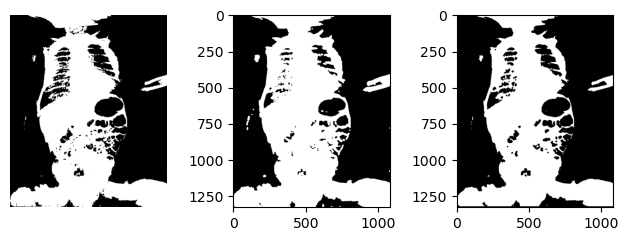

In [34]:
# Crear y ajustar la máscara de hueso
mask_bone = im_ecualizada >= 150
mask_dilate = ndi.binary_dilation(mask_bone, iterations=5)
mask_closed = ndi.binary_closing(mask_bone, iterations=5)
# Trazar imágenes enmascaradas
fig, axes = plt.subplots(1,3)
axes[0].imshow(mask_bone, cmap='gray')
axes[1].imshow(mask_dilate, cmap='gray')
axes[2].imshow(mask_closed, cmap='gray')
# Visualizar imágenes y quitar ejes
fig.axes[0].axis('off')
plt.tight_layout()
plt.show()

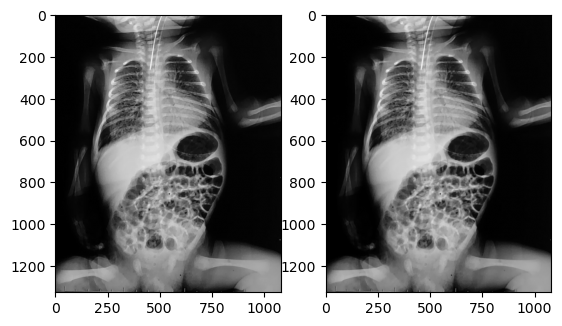

In [32]:
import imageio.v2 as imageio
import scipy.ndimage as ndi
import matplotlib.pyplot as plt
im = imageio.imread('RXNeonato.jpeg')
# Si la imagen tiene 3 canales (RGB), conviértela a escala de grises
if im.ndim == 3:
    im = np.mean(im, axis=2).astype(np.uint8)
else:
    im = im.astype(np.uint8)
# Crear una matriz de tres por tres con pesos de filtro
# Establecer cada elemento en 0,11 para realizar un filtrado de media (también␣→llamado "filtrado uniforme")
weights = [[0.11, 0.11, 0.11],
            [0.11, 0.11, 0.11],
            [0.11, 0.11, 0.11]]
# Convolucionamos la imagen con el filtro
im_filt = ndi.convolve(im, weights)
# Graficamos y visualizamos
fig, axes = plt.subplots(1,2)
axes[0].imshow(im, cmap='gray')
axes[1].imshow(im_filt, cmap='gray')
plt.show()